In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
import sklearn

In [2]:
# import the dataset
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)
df = pd.read_csv(config["input_data"]["file_1"])

In [3]:
from pathlib import Path
import joblib
import json

# Define project-level directories relative to the notebook location
notebook_dir = Path.cwd().resolve()
project_dir = notebook_dir.parent

encoders_path = project_dir / "encoders"
scalers_path = project_dir / "scalers"
models_path = project_dir / "models"
figures_path = project_dir / "figures"

# Create folders if they do not already exist
for folder in [encoders_path, scalers_path, models_path, figures_path]:
    folder.mkdir(parents=True, exist_ok=True)

def save_figure(filename, dpi=300):
    """Save the current Matplotlib figure to the figures folder."""
    output_path = figures_path / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {output_path}")

def save_joblib_artifact(obj, folder, filename, artifact_name):
    """Persist a Python object with joblib."""
    output_path = folder / filename
    joblib.dump(obj, output_path)
    print(f"{artifact_name} saved to: {output_path}")


In [4]:
# check quickly data content
print(df.isnull().sum())
print(df.dtypes)

print(
    df.select_dtypes(include=["object", "string"])
      .nunique()
      .sort_values(ascending=False)
)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               obje

In [5]:
df.dtypes.value_counts()

object     9
float64    8
Name: count, dtype: int64

In [6]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
print(categorical_cols)

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df = df.drop_duplicates()

In [9]:
df["NObeyesdad"].nunique()

7

In [10]:
df["NObeyesdad"].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [11]:
df["NObeyesdad"].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

In [12]:
target = "NObeyesdad"

X = df.drop(columns=[target]).copy()
y = df[target].copy()

In [13]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# feature categorization
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
bin_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
ord_cols = ['CAEC', 'CALC']
nom_cols = ['MTRANS']

In [15]:
# # Creating a new feature: Body Mass Index (BMI) for the training set
X_train['BMI'] = X_train['Weight'] / (X_train['Height'] ** 2)
X_test['BMI'] = X_test['Weight'] / (X_test['Height'] ** 2)

num_cols = num_cols + ['BMI']

In [16]:
# # Defining mapping for binary categorical variables
# Converting text categories into numerical values (0 and 1)
bin_map = {
    'Male': 0,
    'Female': 1,
    'no': 0,
    'yes': 1
}
# Apply the mapping to each binary column in both train and test sets
for col in bin_cols:
    X_train[col] = X_train[col].map(bin_map)
    X_test[col] = X_test[col].map(bin_map)

In [17]:
# Define ordinal mapping for CAEC (Consumption of food between meals)
# Order matters: increasing value = higher frequency
caec_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}
# Define ordinal mapping for CALC (Alcohol consumption)
# Same ordered structure as CAEC
calc_map = {
    'no': 0,
    'Sometimes': 1,
    'Frequently': 2,
    'Always': 3
}
# Apply mapping to CAEC column (train and test)
X_train['CAEC'] = X_train['CAEC'].map(caec_map)
X_test['CAEC'] = X_test['CAEC'].map(caec_map)

# Apply mapping to CALC column (train and test)
X_train['CALC'] = X_train['CALC'].map(calc_map)
X_test['CALC'] = X_test['CALC'].map(calc_map)

In [18]:
# Apply One-Hot Encoding to nominal categorical features
# Converts categorical values into binary columns

X_train = pd.get_dummies(X_train, columns=nom_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nom_cols, drop_first=True)

In [19]:
# Align test set columns with training set columns
# Ensures both datasets have the exact same feature structure

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
label_encoder = LabelEncoder()

# Fit on training target and transform it into numerical labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform test target using the same mapping learned from training
y_test_encoded = label_encoder.transform(y_test)

# Save the fitted label encoder for reuse in future inference
save_joblib_artifact(label_encoder, encoders_path, "label_encoder.pkl", "Label encoder")

# Save the class mapping as JSON for easy inspection outside Python
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
with open(encoders_path / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump({str(k): int(v) for k, v in class_mapping.items()}, f, indent=4)
print(f"Class mapping saved to: {encoders_path / 'class_mapping.json'}")


Label encoder saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\encoders\label_encoder.pkl
Class mapping saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\encoders\class_mapping.json


In [21]:
# Create a mapping between original class labels and their encoded numerical values

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(class_mapping)

{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


In [22]:
from sklearn.preprocessing import StandardScaler
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test set
X_test_scaled = scaler.transform(X_test)

# Save the scaler used for the all-features model
save_joblib_artifact(scaler, scalers_path, "standard_scaler_all_features.pkl", "All-features scaler")


All-features scaler saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\scalers\standard_scaler_all_features.pkl


In [23]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN model with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train (fit) the model using scaled training data and encoded target
knn.fit(X_train_scaled, y_train_encoded)

# Save the baseline all-features KNN model
save_joblib_artifact(knn, models_path, "knn_baseline_all_features.pkl", "Baseline KNN model (all features)")


Baseline KNN model (all features) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_baseline_all_features.pkl


In [24]:
# Generate predictions on the test set
y_pred = knn.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Print overall accuracy of the model and detailed cassification metrics for each class

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8205741626794258

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.71      0.94      0.81        53
      Normal_Weight       0.56      0.49      0.52        57
     Obesity_Type_I       0.90      0.91      0.91        70
    Obesity_Type_II       0.95      0.97      0.96        60
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.76      0.64      0.69        55
Overweight_Level_II       0.81      0.74      0.77        58

           accuracy                           0.82       418
          macro avg       0.81      0.81      0.81       418
       weighted avg       0.82      0.82      0.82       418



Figure saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\figures\confusion_matrix_baseline_all_features.png


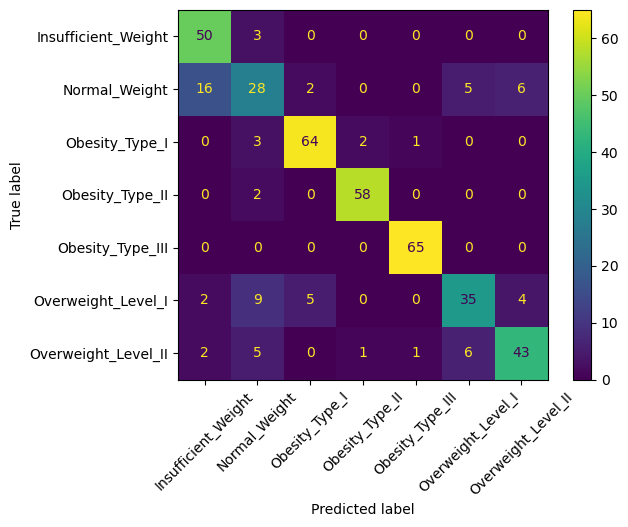

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Compute confusion matrix
# Rows = true labels, Columns = predicted labels

cm = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
save_figure("confusion_matrix_baseline_all_features.png")
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter search space
param_grid = {
    'n_neighbors': list(range(3, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search on training data
grid.fit(X_train_scaled, y_train_encoded)

# Output best hyperparameters found and best cross-validation accuracy
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Save the best estimator and the full GridSearchCV object
best_model_grid = grid.best_estimator_
save_joblib_artifact(best_model_grid, models_path, "knn_gridsearch_all_features.pkl", "Best GridSearch model (all features)")
save_joblib_artifact(grid, models_path, "gridsearch_all_features.pkl", "GridSearchCV object (all features)")


Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best CV score: 0.9107226987466509
Best GridSearch model (all features) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_gridsearch_all_features.pkl
GridSearchCV object (all features) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\gridsearch_all_features.pkl


In [28]:
best_knn = grid.best_estimator_

# best prediction
y_pred_best = best_knn.predict(X_test_scaled)

# Print overall accuracy of the model and detailed cassification metrics for each class

print("Accuracy:", accuracy_score(y_test_encoded, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_best, target_names=label_encoder.classes_))

Accuracy: 0.8971291866028708

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.94      0.90        53
      Normal_Weight       0.71      0.70      0.71        57
     Obesity_Type_I       0.91      0.96      0.93        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.90      0.78      0.83        55
Overweight_Level_II       0.88      0.90      0.89        58

           accuracy                           0.90       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.90      0.90      0.90       418



In [29]:
### worst results after

In [30]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame from your scaled features 
X_vif = pd.DataFrame(
    X_train_scaled,              
    columns=X_train.columns    
)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns

# Calculate VIF for each column
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sort by highest VIF (most collinearity)
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                           feature         VIF
3                           Weight  139.422052
15                             BMI  115.686788
2                           Height   20.411701
0                           Gender    1.998794
1                              Age    1.984883
18    MTRANS_Public_Transportation    1.961166
4   family_history_with_overweight    1.563792
6                             FCVC    1.284571
12                             FAF    1.247634
5                             FAVC    1.225667
8                             CAEC    1.203379
19                  MTRANS_Walking    1.196512
13                             TUE    1.140828
10                            CH2O    1.135736
14                            CALC    1.134827
11                             SCC    1.124413
7                              NCP    1.108849
9                            SMOKE    1.052658
17                MTRANS_Motorbike    1.052110
16                     MTRANS_Bike    1.028551


Figure saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\figures\feature_correlation_heatmap.png


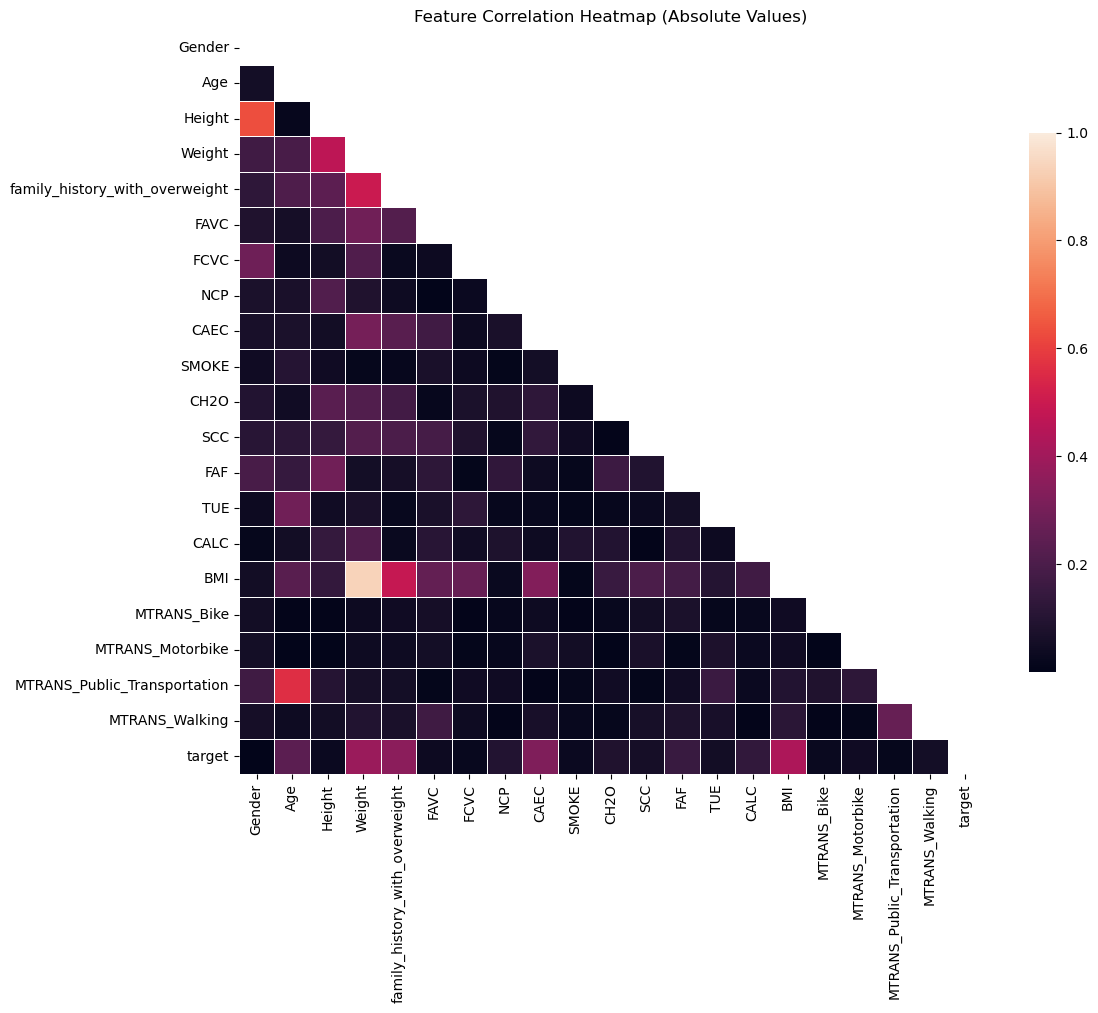

In [31]:
# Combine features and target into a single DataFrame for correlation analysis
df_corr = X_train.copy()

# Add encoded target variable
df_corr["target"] = y_train_encoded

# Compute correlation matrix (absolute values for strength only)
corr = np.abs(df_corr.corr())

# Create mask for upper triangle (to avoid duplicate information)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask,              
    vmax=1,                  
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    annot=False           
)

plt.title("Feature Correlation Heatmap (Absolute Values)")
save_figure("feature_correlation_heatmap.png")
plt.show()

In [32]:
# Create safe copies of the current datasets
# This prevents overwriting the original processed data
X_train_all = X_train.copy()
X_test_all = X_test.copy()

# -----------------------------
# VERSION A: BMI only
# Keep BMI and remove Weight and Height
# -----------------------------
X_train_bmi = X_train_all.drop(columns=['Weight', 'Height'])
X_test_bmi = X_test_all.drop(columns=['Weight', 'Height'])

# Update numerical column list for this specific version
num_cols_bmi = [col for col in num_cols if col not in ['Weight', 'Height']]

# Check resulting shape
print("BMI-only train shape:", X_train_bmi.shape)
print("BMI-only test shape:", X_test_bmi.shape)

# Optional: confirm remaining columns
print("\nBMI-only columns:")
print(X_train_bmi.columns.tolist())

BMI-only train shape: (1669, 18)
BMI-only test shape: (418, 18)

BMI-only columns:
['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


In [33]:

# Initialize scaler
scaler_bmi = StandardScaler()

# Fit on BMI-only training data and transform both sets
X_train_bmi_scaled = scaler_bmi.fit_transform(X_train_bmi)
X_test_bmi_scaled = scaler_bmi.transform(X_test_bmi)

# Train KNN model
knn_bmi = KNeighborsClassifier(n_neighbors=5)
knn_bmi.fit(X_train_bmi_scaled, y_train_encoded)

# Predict on test set
y_pred_bmi = knn_bmi.predict(X_test_bmi_scaled)

# Evaluate
print("BMI-only Accuracy:", accuracy_score(y_test_encoded, y_pred_bmi))
print("\nBMI-only Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_bmi, target_names=label_encoder.classes_))

# Save the scaler and baseline model used for the BMI-only version
save_joblib_artifact(scaler_bmi, scalers_path, "standard_scaler_bmi_only.pkl", "BMI-only scaler")
save_joblib_artifact(knn_bmi, models_path, "knn_baseline_bmi_only.pkl", "Baseline KNN model (BMI-only)")


BMI-only Accuracy: 0.7990430622009569

BMI-only Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.72      0.94      0.82        53
      Normal_Weight       0.58      0.53      0.55        57
     Obesity_Type_I       0.83      0.86      0.85        70
    Obesity_Type_II       0.88      0.95      0.91        60
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.73      0.65      0.69        55
Overweight_Level_II       0.82      0.62      0.71        58

           accuracy                           0.80       418
          macro avg       0.79      0.79      0.79       418
       weighted avg       0.80      0.80      0.79       418

BMI-only scaler saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\scalers\standard_scaler_bmi_only.pkl
Baseline KNN model (BMI-only) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_baseline_bmi_only.pkl


In [34]:
# Define the hyperparameter grid for the BMI-only version
param_grid_bmi = {
    'n_neighbors': list(range(3, 16)),   
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean', 'manhattan'] 
}

# Initialize GridSearchCV for the BMI-only dataset
grid_bmi = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid_bmi,        
    cv=5,                   
    scoring='accuracy',                
    n_jobs=-1                          
)

# Fit the grid search on the scaled BMI-only training data
grid_bmi.fit(X_train_bmi_scaled, y_train_encoded)

# Print best configuration and best cross-validation score
print("Best BMI-only params:", grid_bmi.best_params_)
print("Best BMI-only CV score:", grid_bmi.best_score_)

# Store the best model
best_knn_bmi = grid_bmi.best_estimator_

# Save the tuned BMI-only model and GridSearchCV object
save_joblib_artifact(best_knn_bmi, models_path, "knn_gridsearch_bmi_only.pkl", "Best GridSearch model (BMI-only)")
save_joblib_artifact(grid_bmi, models_path, "gridsearch_bmi_only.pkl", "GridSearchCV object (BMI-only)")


Best BMI-only params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best BMI-only CV score: 0.865785546025067
Best GridSearch model (BMI-only) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_gridsearch_bmi_only.pkl
GridSearchCV object (BMI-only) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\gridsearch_bmi_only.pkl


In [35]:
# -----------------------------
# VERSION B: Weight + Height only
# Remove BMI and keep Weight + Height
# -----------------------------
X_train_wh = X_train_all.drop(columns=['BMI'])
X_test_wh = X_test_all.drop(columns=['BMI'])

# Update the numerical columns list for this version
num_cols_wh = [col for col in num_cols if col != 'BMI']

# Check the resulting dataset shapes
print("Weight+Height train shape:", X_train_wh.shape)
print("Weight+Height test shape:", X_test_wh.shape)

# -----------------------------
# Scale the Weight + Height version
# -----------------------------
scaler_wh = StandardScaler()

# Fit the scaler on the training set and transform both datasets
X_train_wh_scaled = scaler_wh.fit_transform(X_train_wh)
X_test_wh_scaled = scaler_wh.transform(X_test_wh)


Weight+Height train shape: (1669, 19)
Weight+Height test shape: (418, 19)


In [36]:
# -----------------------------
# Grid search for the Weight + Height version
# -----------------------------
param_grid_wh = {
    'n_neighbors': list(range(3, 16)),   
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean', 'manhattan']
}

grid_wh = GridSearchCV(
    estimator=KNeighborsClassifier(),  
    param_grid=param_grid_wh,         
    cv=5,                             
    scoring='accuracy',                
    n_jobs=-1                       
)

# Fit the grid search on the scaled Weight + Height training set
grid_wh.fit(X_train_wh_scaled, y_train_encoded)

# Print best hyperparameters and best CV score
print("Best Weight+Height params:", grid_wh.best_params_)
print("Best Weight+Height CV score:", grid_wh.best_score_)

# Store the best model for later prediction
best_knn_wh = grid_wh.best_estimator_

# Save the tuned Weight+Height model and GridSearchCV object
save_joblib_artifact(best_knn_wh, models_path, "knn_gridsearch_weight_height.pkl", "Best GridSearch model (Weight+Height)")
save_joblib_artifact(grid_wh, models_path, "gridsearch_weight_height.pkl", "GridSearchCV object (Weight+Height)")


Best Weight+Height params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Weight+Height CV score: 0.8675909442376508
Best GridSearch model (Weight+Height) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_gridsearch_weight_height.pkl
GridSearchCV object (Weight+Height) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\gridsearch_weight_height.pkl


In [37]:
# Initialize scaler for Weight + Height version
scaler_wh = StandardScaler()

# Fit on Weight+Height training data and transform both sets
X_train_wh_scaled = scaler_wh.fit_transform(X_train_wh)
X_test_wh_scaled = scaler_wh.transform(X_test_wh)

# Train KNN model (use best k from GridSearch if available)
knn_wh = KNeighborsClassifier(n_neighbors=5)

# Fit model
knn_wh.fit(X_train_wh_scaled, y_train_encoded)

# Predict on test set
y_pred_wh = knn_wh.predict(X_test_wh_scaled)

# Evaluate
print("Weight+Height Accuracy:", accuracy_score(y_test_encoded, y_pred_wh))

print("\nWeight+Height Classification Report:\n")
print(classification_report(
    y_test_encoded,
    y_pred_wh,
    target_names=label_encoder.classes_
))

# Save the scaler and baseline model used for the Weight+Height version
save_joblib_artifact(scaler_wh, scalers_path, "standard_scaler_weight_height.pkl", "Weight+Height scaler")
save_joblib_artifact(knn_wh, models_path, "knn_baseline_weight_height.pkl", "Baseline KNN model (Weight+Height)")


Weight+Height Accuracy: 0.8014354066985646

Weight+Height Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.69      0.94      0.80        53
      Normal_Weight       0.55      0.46      0.50        57
     Obesity_Type_I       0.84      0.89      0.86        70
    Obesity_Type_II       0.88      0.97      0.92        60
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.77      0.62      0.69        55
Overweight_Level_II       0.83      0.69      0.75        58

           accuracy                           0.80       418
          macro avg       0.79      0.79      0.79       418
       weighted avg       0.80      0.80      0.79       418

Weight+Height scaler saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\scalers\standard_scaler_weight_height.pkl
Baseline KNN model (Weight+Height) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\k

In [38]:
# -----------------------------
# VERSION D: Weight + BMI (no Height)
# -----------------------------
X_train_wb = X_train_all.drop(columns=['Height'])
X_test_wb = X_test_all.drop(columns=['Height'])

# Check shapes
print("Weight+BMI train shape:", X_train_wb.shape)
print("Weight+BMI test shape:", X_test_wb.shape)

Weight+BMI train shape: (1669, 19)
Weight+BMI test shape: (418, 19)


In [39]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler_wb = StandardScaler()

# Fit on training data and transform both sets
X_train_wb_scaled = scaler_wb.fit_transform(X_train_wb)
X_test_wb_scaled = scaler_wb.transform(X_test_wb)

# Save the scaler used for the Weight+BMI version
save_joblib_artifact(scaler_wb, scalers_path, "standard_scaler_weight_bmi.pkl", "Weight+BMI scaler")


Weight+BMI scaler saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\scalers\standard_scaler_weight_bmi.pkl


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_wb = {
    'n_neighbors': list(range(3, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_wb = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_wb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_wb.fit(X_train_wb_scaled, y_train_encoded)

print("Best Weight+BMI params:", grid_wb.best_params_)
print("Best Weight+BMI CV score:", grid_wb.best_score_)

Best Weight+BMI params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best Weight+BMI CV score: 0.9065256873640107


In [41]:
from sklearn.metrics import accuracy_score, classification_report

best_knn_wb = grid_wb.best_estimator_

# Predict
y_pred_wb = best_knn_wb.predict(X_test_wb_scaled)

# Evaluate
print("Weight+BMI Accuracy:", accuracy_score(y_test_encoded, y_pred_wb))

print("\nWeight+BMI Classification Report:\n")
print(classification_report(
    y_test_encoded,
    y_pred_wb,
    target_names=label_encoder.classes_
))

# Save the tuned Weight+BMI model and GridSearchCV object
save_joblib_artifact(best_knn_wb, models_path, "knn_gridsearch_weight_bmi.pkl", "Best GridSearch model (Weight+BMI)")
save_joblib_artifact(grid_wb, models_path, "gridsearch_weight_bmi.pkl", "GridSearchCV object (Weight+BMI)")


Weight+BMI Accuracy: 0.8708133971291866

Weight+BMI Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.82      0.94      0.88        53
      Normal_Weight       0.64      0.61      0.62        57
     Obesity_Type_I       0.92      0.96      0.94        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.81      0.76      0.79        55
Overweight_Level_II       0.87      0.81      0.84        58

           accuracy                           0.87       418
          macro avg       0.86      0.87      0.86       418
       weighted avg       0.87      0.87      0.87       418

Best GridSearch model (Weight+BMI) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_gridsearch_weight_bmi.pkl
GridSearchCV object (Weight+BMI) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\

In [43]:
###############

In [44]:
import time
import numpy as np
import pandas as pd
import scipy.stats as st
import optuna

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Define the Optuna objective function
def objective(trial, confidence_level, folds):
    """
    Optimize KNN hyperparameters for a classification task using cross-validation accuracy.
    Also stores a confidence interval for the mean CV accuracy in each trial.
    """

    # Suggest hyperparameters to test
    n_neighbors = trial.suggest_int("n_neighbors", 2, 25)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_int("p", 1, 3)  # 1=Manhattan, 2=Euclidean, 3=other Minkowski variant

    # Initialize KNN classifier
    knn = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    # Perform cross-validation using accuracy as the scoring metric
    scores = cross_val_score(
        knn,
        X_train_scaled,      # Use the scaled full-feature training set
        y_train_encoded,
        cv=folds,
        scoring="accuracy"
    )

    # Compute mean CV score
    mean_score = np.mean(scores)

    # Compute standard error of the mean
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Compute confidence interval using Student's t distribution
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval as trial metadata
    trial.set_user_attr(
        "CV_score_summary",
        [
            round(lower_bound, 4),
            round(mean_score, 4),
            round(upper_bound, 4)
        ]
    )

    # Optuna will maximize accuracy
    return mean_score


# Set optimization settings
confidence_level = 0.95
folds = 10

# Create Optuna study
start_time = time.time()

study = optuna.create_study(direction="maximize")

# Run optimization
study.optimize(
    lambda trial: objective(trial, confidence_level, folds),
    n_trials=45
)

end_time = time.time()

# Print optimization summary
print("\n")
print(f"Time taken to find the best hyperparameter combination: {end_time - start_time:.4f} seconds")
print("\n")
print("Best hyperparameters found:", study.best_params)
print(f"Best CV accuracy found: {study.best_value:.4f}")

# Save the Optuna study object for future inspection
save_joblib_artifact(study, models_path, "optuna_study_all_features.pkl", "Optuna study (all features)")


[I 2026-04-02 16:39:23,651] A new study created in memory with name: no-name-3104e381-057e-48e4-8140-ece8de9067bc
[I 2026-04-02 16:39:24,070] Trial 0 finished with value: 0.7034016304739918 and parameters: {'n_neighbors': 23, 'weights': 'uniform', 'p': 3}. Best is trial 0 with value: 0.7034016304739918.
[I 2026-04-02 16:39:24,123] Trial 1 finished with value: 0.7968616982901666 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 0.7968616982901666.
[I 2026-04-02 16:39:24,172] Trial 2 finished with value: 0.8400259721520813 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: 0.8400259721520813.
[I 2026-04-02 16:39:24,219] Trial 3 finished with value: 0.8322343265276675 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 0.8400259721520813.
[I 2026-04-02 16:39:24,269] Trial 4 finished with value: 0.8304162758819709 and parameters: {'n_neighbors': 9, 'weights': '



Time taken to find the best hyperparameter combination: 3.3685 seconds


Best hyperparameters found: {'n_neighbors': 4, 'weights': 'distance', 'p': 1}
Best CV accuracy found: 0.9149
Optuna study (all features) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\optuna_study_all_features.pkl


In [45]:
# Collect trial results and sort them by mean CV accuracy (highest first)
results = sorted(
    [
        (
            index,
            trial.user_attrs["CV_score_summary"][0],  # lower bound
            trial.user_attrs["CV_score_summary"][1],  # mean
            trial.user_attrs["CV_score_summary"][2]   # upper bound
        )
        for index, trial in enumerate(study.trials)
        if "CV_score_summary" in trial.user_attrs
    ],
    key=lambda x: x[2],  # sort by upper bound if you want a more optimistic ranking
    reverse=True
)

# Print confidence interval for the best trial
print("The accuracy confidence interval for the best hyperparameter combination is:")
print(results[0][1:])

The accuracy confidence interval for the best hyperparameter combination is:
(np.float64(0.8938), np.float64(0.9149), np.float64(0.9361))


In [46]:
best_trial = study.best_trial

print("Best trial confidence interval:")
print(best_trial.user_attrs["CV_score_summary"])

Best trial confidence interval:
[np.float64(0.8938), np.float64(0.9149), np.float64(0.9361)]


In [47]:
# Initialize the final KNN model using the best hyperparameters from Optuna
best_model_optuna = KNeighborsClassifier(
    n_neighbors=study.best_params["n_neighbors"],
    weights=study.best_params["weights"],
    p=study.best_params["p"]
)

# Fit the final model on the full scaled training set
best_model_optuna.fit(X_train_scaled, y_train_encoded)

# Predict on the scaled test set
y_pred_optuna = best_model_optuna.predict(X_test_scaled)

# Evaluate test performance
print(f"Test Accuracy: {accuracy_score(y_test_encoded, y_pred_optuna):.4f}")
print("\nClassification Report:\n")
print(classification_report(
    y_test_encoded,
    y_pred_optuna,
    target_names=label_encoder.classes_
))

# Save the final Optuna-tuned model
save_joblib_artifact(best_model_optuna, models_path, "knn_optuna_all_features.pkl", "Optuna-tuned KNN model (all features)")


Test Accuracy: 0.8971

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.94      0.90        53
      Normal_Weight       0.71      0.70      0.71        57
     Obesity_Type_I       0.91      0.96      0.93        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.90      0.78      0.83        55
Overweight_Level_II       0.88      0.90      0.89        58

           accuracy                           0.90       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.90      0.90      0.90       418

Optuna-tuned KNN model (all features) saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\knn_optuna_all_features.pkl


Figure saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\figures\confusion_matrix_optuna_all_features.png


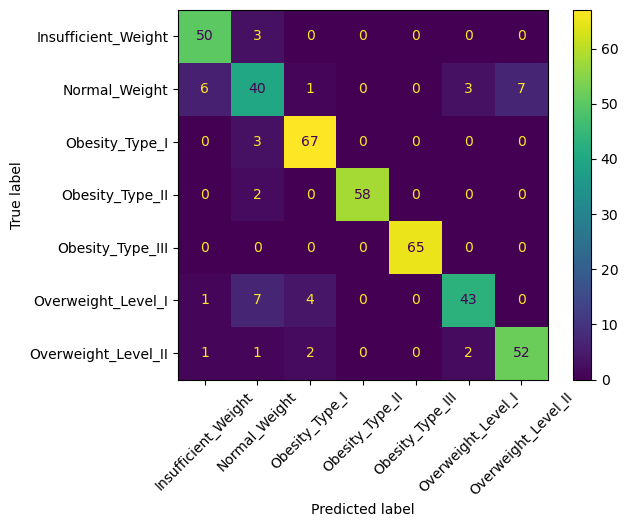

In [48]:
# Compute confusion matrix
cm_optuna = confusion_matrix(y_test_encoded, y_pred_optuna)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=label_encoder.classes_
)

disp.plot(xticks_rotation=45)
save_figure("confusion_matrix_optuna_all_features.png")
plt.show()

In [49]:
import pandas as pd
from sklearn.metrics import accuracy_score

# -----------------------------
# GRIDSEARCH RESULTS
# -----------------------------
# Get the best model found by GridSearchCV
best_model_grid = grid.best_estimator_

# Generate predictions on the test set
y_pred_grid = best_model_grid.predict(X_test_scaled)

# Compute test accuracy
grid_test_accuracy = accuracy_score(y_test_encoded, y_pred_grid)

# Store GridSearch results in a dictionary
grid_results = {
    "Method": "GridSearchCV",
    "Best Params": str(grid.best_params_),
    "Best CV Score": round(grid.best_score_, 4),
    "Test Accuracy": round(grid_test_accuracy, 4)
}

# -----------------------------
# OPTUNA RESULTS
# -----------------------------
# Generate predictions on the test set using the best Optuna model
y_pred_optuna = best_model_optuna.predict(X_test_scaled)

# Compute test accuracy
optuna_test_accuracy = accuracy_score(y_test_encoded, y_pred_optuna)

# Store Optuna results in a dictionary
optuna_results = {
    "Method": "Optuna",
    "Best Params": str(study.best_params),
    "Best CV Score": round(study.best_value, 4),
    "Test Accuracy": round(optuna_test_accuracy, 4)
}

# -----------------------------
# COMBINE INTO A SINGLE TABLE
# -----------------------------
comparison_df = pd.DataFrame([grid_results, optuna_results])

# Display comparison table
print(comparison_df)

         Method                                        Best Params  \
0  GridSearchCV  {'metric': 'manhattan', 'n_neighbors': 4, 'wei...   
1        Optuna  {'n_neighbors': 4, 'weights': 'distance', 'p': 1}   

   Best CV Score  Test Accuracy  
0         0.9107         0.8971  
1         0.9149         0.8971  


In [50]:
# Extract confidence interval from best Optuna trial
optuna_ci = best_trial.user_attrs["CV_score_summary"]

# Add confidence interval to the Optuna results
optuna_results = {
    "Method": "Optuna",
    "Best Params": str(study.best_params),
    "Best CV Score": round(study.best_value, 4),
    "CV 95% CI": str(optuna_ci),
    "Test Accuracy": round(optuna_test_accuracy, 4)
}

# For GridSearch, CI is not available unless manually computed
grid_results = {
    "Method": "GridSearchCV",
    "Best Params": str(grid.best_params_),
    "Best CV Score": round(grid.best_score_, 4),
    "CV 95% CI": "Not computed",
    "Test Accuracy": round(grid_test_accuracy, 4)
}

comparison_df = pd.DataFrame([grid_results, optuna_results])

print(comparison_df)

         Method                                        Best Params  \
0  GridSearchCV  {'metric': 'manhattan', 'n_neighbors': 4, 'wei...   
1        Optuna  {'n_neighbors': 4, 'weights': 'distance', 'p': 1}   

   Best CV Score                                          CV 95% CI  \
0         0.9107                                       Not computed   
1         0.9149  [np.float64(0.8938), np.float64(0.9149), np.fl...   

   Test Accuracy  
0         0.8971  
1         0.8971  


In [51]:
comparison_df = pd.DataFrame([
    {
        "Method": "GridSearchCV",
        "n_neighbors": grid.best_params_["n_neighbors"],
        "weights": grid.best_params_["weights"],
        "metric_or_p": grid.best_params_.get("metric", "N/A"),
        "Best CV Score": round(grid.best_score_, 4),
        "Test Accuracy": round(grid_test_accuracy, 4)
    },
    {
        "Method": "Optuna",
        "n_neighbors": study.best_params["n_neighbors"],
        "weights": study.best_params["weights"],
        "metric_or_p": study.best_params["p"],
        "Best CV Score": round(study.best_value, 4),
        "Test Accuracy": round(optuna_test_accuracy, 4)
    }
])

print(comparison_df)

# Save the final comparison table as a CSV file
comparison_output_path = models_path / "gridsearch_vs_optuna_comparison.csv"
comparison_df.to_csv(comparison_output_path, index=False)
print(f"Comparison table saved to: {comparison_output_path}")


         Method  n_neighbors   weights metric_or_p  Best CV Score  \
0  GridSearchCV            4  distance   manhattan         0.9107   
1        Optuna            4  distance           1         0.9149   

   Test Accuracy  
0         0.8971  
1         0.8971  
Comparison table saved to: C:\Users\Utilizador\Desktop\IronHack\Week7\Day1\ml-project\models\gridsearch_vs_optuna_comparison.csv
